Confidence set thresholds for the generalised log-likelihood function

Lotka-Volterra predator-prey model

Alexander Johnston Queensland University of Technology a44.johnston@qut.edu.au

In [1]:
using Plots, DelimitedFiles, Interpolations, Optim, DifferentialEquations, SparseArrays, Interpolations, Random, Distributions, NLopt, Dierckx, LaTeXStrings, BSplineKit, Plots.PlotMeasures, LinearAlgebra
gr()

plot_font = "Computer Modern"
default(fontfamily=plot_font,linewidth=1,framestyle=:box,label=nothing,grid=true)

#Model parameters
alpha = 1;
beta = 1;

a = [alpha, beta];

#Initial conditions
x0 = 1;
y0 = 0.5;

#Model
a = [alpha, beta];

#Number of synthetic data points
N_data = 41;

#Ratio of number of points in the spline grid to the number of points in the synthetic data set 
grid_ratio = 10;

#Number of B-Splines
df = N_data - 1;

#Discretisation grid size for spline
N_t = grid_ratio*df;

tmax = 25
tt=LinRange(0,tmax,N_t);
t_start = 0;
t_end = 25;
tt = LinRange(t_start, t_end, N_t);

#Standard deviation of additive Gaussian noise used to generate the synthetic data
sigma=0.01; 



Creating synthetic data sets.

In [2]:
#Create synthetic data for the Lotka-Volterra predator-prey model.

#Lotka-Volterra predator-prey equations
function Lotka_Volterra!(du,u,a,t)
alpha = a[1];
beta = a[2];
du[1]=alpha*u[1] - u[1]*u[2]; 
du[2]=beta*u[1]*u[2] - u[2];
end

function odesolver(t,ic,a)
tspan=(0.0,maximum(t))
prob=ODEProblem(Lotka_Volterra!,ic,tspan, a)
alg=Tsit5()
sol=solve(prob,alg,saveat=t);
return sol
end

ic=[x0, y0]
sol = odesolver(tt,ic,a)
    
x = sol[1,:];
y = sol[2,:];

t = [0]
for (i, t_i) in enumerate(tt)
    if i%grid_ratio == 0
        t = vcat(t, t_i)
    end
end
        
sol_true = sol = odesolver(tt,ic,a)
x_true = sol[1,:];
y_true = sol[2,:];

#Create stochastic data using additive Gaussian noise applied at each data point for the true solution

dist=Normal(0,sigma);

x_model_subset = [x_true[1]];
y_model_subset = [y_true[1]];
for (i, t_i) in enumerate(tt)
    if i%grid_ratio == 0
        x_model_subset = vcat(x_model_subset, x_true[i])
        y_model_subset = vcat(y_model_subset, y_true[i])
    end
end

x_data_sample = zeros(length(x_model_subset));
y_data_sample = zeros(length(y_model_subset));

for (i, x_model_i) in enumerate(x_model_subset)
    x_data_sample[i] = x_model_i + rand(dist)
end

for (i, y_model_i) in enumerate(y_model_subset)
    y_data_sample[i] = y_model_i + rand(dist)
end

t_data = t;
t_model = tt;

x_data = x_data_sample;
y_data = y_data_sample;


x_model = x_true;
y_model = y_true;


Here we define the necessary functions to run the generalised profiling method. This involves constructing a B-Spline matrix and writing a function for the generalised log-likelihood.

In [3]:
#Construct a B-Spline matrix

spline_order = BSplineKit.BSplineOrder(4)  # This corresponds to cubic splines
B = BSplineKit.BSplineBasis(spline_order, LinRange(t_start, t_end, df-1))

B_matrix = collocation_matrix(B, tt, BSplineKit.Derivative(0), SparseMatrixCSC{Float64})
B_matrix[:,1] = ones(N_t)

#Construct a vector of indices, i_obs, showing the indices of the fine grid of true data, tt, that correspond to values of the synthetic data subset, t

i_obs_x = []
for (i, t_i) in enumerate(t_model)
    if t_i in t_data
        append!(i_obs_x,i)
    end
end

i_obs_y = []
for (i, t_i) in enumerate(t_model)
    if t_i in t_data
        append!(i_obs_y,i)
    end
end


#Construct an A_obs matrix. This matrix constructs a matrix in which each row consists of zeros and a single one. The location of the single one is specificed by the index of the i_obs vector.

t_model = collect(t_model)

function create_A_obs(i_obs)
    A_obs = zeros(Int, length(i_obs), length(t_model))
    for i in range(1, length(i_obs))
        A_obs[i, i_obs[i]] = 1
    end
    A_obs
end

#Construct A_obs, B_obs, and beta_est

 xy_data = vcat(x_data, y_data);
 xy_model = vcat(x_model, y_model);

 A_obs_x = create_A_obs(i_obs_x);
 A_obs_y = create_A_obs(i_obs_y);
 A_obs = A_obs_x;
 B_obs_x = A_obs_x*B_matrix;
 B_obs_y = A_obs_y*B_matrix;
 B_obs = B_obs_x;
 beta_x = pinv(B_obs)*x_data;
 beta_y = pinv(B_obs)*y_data;

#Construct first and second derivative matrix approximations

N = length(x_model)
dt = t_model[end]/(N-1)
D1 = diagm(-1 => -1*ones(N-1), 0 => 0*ones(N-1), 1 => ones(N-1))
D1 = (1 / (2*dt))*D1[1:N, :];
D1[1, 1] = -1/dt;
D1[1, 2] = 1/dt;
D1[N, N-1] = -1/dt;
D1[N, N] = 1/dt;

D1B = D1*B_matrix;

#Loglikelihood functions

function loglhood_sum(w,x_data,y_data,model_x,model_y,a,sigma)
    B_obs_aug_x = vcat(B_obs_x, w*dt*D1B);
    B_obs_aug_y = vcat(B_obs_y, w*dt*D1B);
    
    RHS_term_x = a[1]*model_x - model_x.*model_y;
    RHS_term_y = a[2]*model_x.*model_y - model_y;
   
    x_data_aug = vcat(x_data, w*dt*RHS_term_x);
    y_data_aug = vcat(y_data, w*dt*RHS_term_y);
    
    betas_x = B_obs_aug_x \ x_data_aug;
    betas_y = B_obs_aug_y \ y_data_aug;

    model_x = B_matrix*betas_x;
    model_y = B_matrix*betas_y;  
    
    g=vcat(A_obs_x*B_matrix*betas_x, A_obs_y*B_matrix*betas_y);
    y1 = vcat(x_data, y_data);
    dist=Normal(0,sigma);  

    Dx = D1B*betas_x;
    Dy = D1B*betas_y;

    y2= vcat(Dx, Dy);
    
    f = vcat(a[1]*model_x - model_x.*model_y, a[2]*model_x.*model_y - model_y);   
    
    e3=loglikelihood(dist, (y1.-g));
    e4 = sum(e3) - w*norm((y2 - f))^2; 
    return e4

end;

#New values of w based on standard deviations of results from previous step

function standard_deviation_data_norms(x_data,y_data,betas_x,betas_y,a,sigma)
    g=vcat(A_obs_x*B_matrix*betas_x, A_obs_y*B_matrix*betas_y);
    y = vcat(x_data, y_data);
    dist=Normal(0,sigma);  

    Dx = D1B*betas_x;
    Dy = D1B*betas_y;

    y2= vcat(Dx, Dy);
    
    f = vcat(a[1]*model_x - model_x.*model_y, a[2]*model_x.*model_y - model_y);
    
    e=std((y.-g));
    return e
end;

function standard_deviation_model_norms(betas_x,betas_y,a,sigma)
    Dx = D1B*betas_x;
    Dy = D1B*betas_y;
                    
    y2= vcat(Dx, Dy);

    model_x = B_matrix*betas_x;
    model_y = B_matrix*betas_y;
    
    f = vcat(a[1]*model_x - model_x.*model_y, a[2]*model_x.*model_y - model_y);
                          
    e=std(w*(y2 - f));
    return e
end;

#Optimising the likelihood

function Optimise(fun,θ₀,lb,ub)    
    tomax=(θ,∂θ)->fun(θ)
    opt=Opt(:LN_NELDERMEAD,length(θ₀))
    opt.max_objective=tomax
    opt.lower_bounds=lb      
    opt.upper_bounds=ub
    opt.maxtime=1*60
    res = NLopt.optimize(opt,θ₀)
    return res[[2,1]];
end

function funmle_sum(a)
return loglhood_sum(w,x_data,y_data,model_x,model_y,a,sigma);
end



funmle_sum (generic function with 1 method)

Here we write a function that can be used for a coverage test. Each trial involves conducting the iterative generalised profiling procedure for three iterations and producing a parameter estimate.

In [4]:
function coverage_test()

    #Loglikelihood functions

    function loglhood_sum(w,x_data,y_data,model_x,model_y,a,sigma)
        B_obs_aug_x = vcat(B_obs_x, w*dt*D1B);
        B_obs_aug_y = vcat(B_obs_y, w*dt*D1B);
        
        RHS_term_x = a[1]*model_x - model_x.*model_y;
        RHS_term_y = a[2]*model_x.*model_y - model_y;
       
        x_data_aug = vcat(x_data, w*dt*RHS_term_x);
        y_data_aug = vcat(y_data, w*dt*RHS_term_y);
        
        betas_x = B_obs_aug_x \ x_data_aug;
        betas_y = B_obs_aug_y \ y_data_aug;
    
        model_x = B_matrix*betas_x;
        model_y = B_matrix*betas_y;  
        
        g=vcat(A_obs_x*B_matrix*betas_x, A_obs_y*B_matrix*betas_y);
        y1 = vcat(x_data, y_data);
        dist=Normal(0,sigma);  
    
        Dx = D1B*betas_x;
        Dy = D1B*betas_y;
    
        y2= vcat(Dx, Dy);
        
        f = vcat(a[1]*model_x - model_x.*model_y, a[2]*model_x.*model_y - model_y);   
        
        e3=loglikelihood(dist, (y1.-g));
        e4 = sum(e3) - w*norm((y2 - f))^2; 
        return e4
    
    end;
    
    #New values of w based on standard deviations of results from previous step
    
    function standard_deviation_data_norms(x_data,y_data,betas_x,betas_y,a,sigma)
        g=vcat(A_obs_x*B_matrix*betas_x, A_obs_y*B_matrix*betas_y);
        y = vcat(x_data, y_data);
        dist=Normal(0,sigma);  
    
        Dx = D1B*betas_x;
        Dy = D1B*betas_y;
    
        y2= vcat(Dx, Dy);
        
        f = vcat(a[1]*model_x - model_x.*model_y, a[2]*model_x.*model_y - model_y);
        
        e=std((y.-g));
        return e
    end;
    
    function standard_deviation_model_norms(betas_x,betas_y,a,sigma)
        Dx = D1B*betas_x;
        Dy = D1B*betas_y;
                        
        y2= vcat(Dx, Dy);
    
        model_x = B_matrix*betas_x;
        model_y = B_matrix*betas_y;
        
        f = vcat(a[1]*model_x - model_x.*model_y, a[2]*model_x.*model_y - model_y);
                              
        e=std(w*(y2 - f));
        return e
    end;
    
    #Optimising the likelihood

    function Optimise(fun,θ₀,lb,ub)    
        tomax=(θ,∂θ)->fun(θ)
        opt=Opt(:LN_NELDERMEAD,length(θ₀))
        opt.max_objective=tomax
        opt.lower_bounds=lb      
        opt.upper_bounds=ub
        opt.maxtime=1*60
        res = NLopt.optimize(opt,θ₀)
        return res[[2,1]];
    end
    
    function funmle_sum(a)
    return loglhood_sum(w,x_data,y_data,model_x,model_y,a,sigma);
    end

    #Sum analysis
    alphamin= 0.8;
    alphamax = 1.3;
    betamin=0.8;
    betamax=1.3;
    
    #Initial regularisation parameter
    
    w = 0;
    
    alpha_test = 1.1;
    beta_test = 0.9;
    
    a_test = [alpha_test, beta_test];
    
    x_model_test = ones(N);
    y_model_test = ones(N);
    
    model_x = x_model_test;
    model_y = y_model_test;
    
    θG=a_test;
    lb=[alphamin,betamin]
    ub=[alphamax,alphamax]
    
    #Sum analysis
    
    (xopt_sum,fopt_sum)=Optimise(funmle_sum,θG,lb,ub)
    alphamle_sum=xopt_sum[1]
    betamle_sum=xopt_sum[2]
    
    #Solving the linear algebra optimisation problem
    
    B_obs_aug_x = vcat(B_obs_x, w*dt*D1B);
    B_obs_aug_y = vcat(B_obs_y, w*dt*D1B);
    
    RHS_term_x = a[1]*model_x - model_x.*model_y;
    RHS_term_y = a[2]*model_x.*model_y - model_y;
    
    x_data_aug = vcat(x_data, w*dt*RHS_term_x);
    y_data_aug = vcat(y_data, w*dt*RHS_term_y);
    
    betas_x_sum = B_obs_aug_x \ x_data_aug;
    betas_y_sum = B_obs_aug_y \ y_data_aug;
    
    Dx = D1B*betas_x_sum;
    Dy = D1B*betas_y_sum;
    
    y2= vcat(Dx, Dy);
    
    f = vcat(a[1]*model_x - model_x.*model_y, a[2]*model_x.*model_y - model_y);  
    
    B_matrix_betas_x_sum = B_matrix*betas_x_sum;
    B_matrix_betas_y_sum = B_matrix*betas_y_sum;
    
    
    #New weight and parameters
    
    w = 10^(-2);
    
    (xopt_sum,fopt_sum)=Optimise(funmle_sum,θG,lb,ub)
    alphamle_sum=xopt_sum[1]
    betamle_sum=xopt_sum[2]
    
    a_test = [alphamle_sum, betamle_sum];
    betas_x = betas_x_sum;
    betas_y = betas_y_sum;
    model_x = B_matrix*betas_x;
    model_y = B_matrix*betas_y;  
    
    
    #Solving the linear algebra optimisation problem
    
    B_obs_aug_x_1 = vcat(B_obs_x, w*dt*D1B);
    B_obs_aug_y_1 = vcat(B_obs_y, w*dt*D1B);
    
    RHS_term_x_1 = alphamle_sum*model_x - model_x.*model_y;
    RHS_term_y_1 = betamle_sum*model_x.*model_y - model_y;
    
    x_data_aug = vcat(x_data, w*dt*RHS_term_x);
    y_data_aug = vcat(y_data, w*dt*RHS_term_y);
    
    betas_x_sum_1 = B_obs_aug_x_1 \ x_data_aug;
    betas_y_sum_1 = B_obs_aug_y_1 \ y_data_aug;
    
    Dx_1 = D1B*betas_x_sum_1;
    Dy_1 = D1B*betas_y_sum_1;
    
    y2= vcat(Dx_1, Dy_1);
    
    f = vcat(alphamle_sum*model_x - model_x.*model_y, betamle_sum*model_x.*model_y - model_y);  
    
    B_matrix_betas_x_sum_1 = B_matrix*betas_x_sum_1;
    B_matrix_betas_y_sum_1 = B_matrix*betas_y_sum_1;
    
    #New weight and parameters
    
    (xopt_sum,fopt_sum)=Optimise(funmle_sum,θG,lb,ub)
    alphamle_sum=xopt_sum[1]
    betamle_sum=xopt_sum[2]
    
    a_test = [alphamle_sum, betamle_sum];
    betas_x = betas_x_sum_1;
    betas_y = betas_y_sum_1;
    model_x = B_matrix*betas_x;
    model_y = B_matrix*betas_y;  
    
    w = (standard_deviation_data_norms(x_data, y_data, betas_x, betas_y, a_test, sigma))/(standard_deviation_model_norms(betas_x, betas_y, a_test, sigma));
    
    #Solving the linear algebra optimisation problem
    
    B_obs_aug_x_2 = vcat(B_obs_x, w*dt*D1B);
    B_obs_aug_y_2 = vcat(B_obs_y, w*dt*D1B);
    
    RHS_term_x_2 = alphamle_sum*model_x - model_x.*model_y;
    RHS_term_y_2 = betamle_sum*model_x.*model_y - model_y;
    
    x_data_aug = vcat(x_data, w*dt*RHS_term_x);
    y_data_aug = vcat(y_data, w*dt*RHS_term_y);
    
    betas_x_sum_2 = B_obs_aug_x_2 \ x_data_aug;
    betas_y_sum_2 = B_obs_aug_y_2 \ y_data_aug;
    
    Dx_2 = D1B*betas_x_sum_2;
    Dy_2 = D1B*betas_y_sum_2;
    
    y2= vcat(Dx_2, Dy_2);
    
    f = vcat(alphamle_sum*model_x - model_x.*model_y, betamle_sum*model_x.*model_y - model_y);  
    
    B_matrix_betas_x_sum_2 = B_matrix*betas_x_sum_2;
    B_matrix_betas_y_sum_2 = B_matrix*betas_y_sum_2;
    
    #New weight and parameters
    
    (xopt_sum,fopt_sum)=Optimise(funmle_sum,θG,lb,ub)
    alphamle_sum=xopt_sum[1]
    betamle_sum=xopt_sum[2]
    
    a_test = [alphamle_sum, betamle_sum];
    betas_x = betas_x_sum_2;
    betas_y = betas_y_sum_2;
    model_x = B_matrix*betas_x;
    model_y = B_matrix*betas_y;  
    
    w = (standard_deviation_data_norms(x_data, y_data, betas_x, betas_y, a_test, sigma))/(standard_deviation_model_norms(betas_x, betas_y, a_test, sigma));

    #Solving the linear algebra optimisation problem
    
    B_obs_aug_x_3 = vcat(B_obs_x, w*dt*D1B);
    B_obs_aug_y_3 = vcat(B_obs_y, w*dt*D1B);
    
    RHS_term_x_3 = alphamle_sum*model_x - model_x.*model_y;
    RHS_term_y_3 = betamle_sum*model_x.*model_y - model_y;
    
    x_data_aug = vcat(x_data, w*dt*RHS_term_x);
    y_data_aug = vcat(y_data, w*dt*RHS_term_y);
    
    betas_x_sum_3 = B_obs_aug_x_3 \ x_data_aug;
    betas_y_sum_3 = B_obs_aug_y_3 \ y_data_aug;
    
    Dx_3 = D1B*betas_x_sum_3;
    Dy_3 = D1B*betas_y_sum_3;
    
    y2= vcat(Dx_3, Dy_3);
    
    f = vcat(alphamle_sum*model_x - model_x.*model_y, betamle_sum*model_x.*model_y - model_y);  
    
    B_matrix_betas_x_sum_3 = B_matrix*betas_x_sum_3;
    B_matrix_betas_y_sum_3 = B_matrix*betas_y_sum_3;

    (xopt_sum,fopt_sum)=Optimise(funmle_sum,θG,lb,ub)
    alphamle_sum=xopt_sum[1]
    betamle_sum=xopt_sum[2]
    
    return [alphamle_sum, betamle_sum, betas_x_sum_3, betas_y_sum_3, w]

end

coverage_test (generic function with 1 method)

We now run a coverage test by producing a series of estimates using different synthetic data sets (generated with the same model parameters and with additive Gaussian noise with the same standard deviation). In the paper, we use 2000 trials.

In [5]:
t1 = time();

N_iterations = 2000;

alphamle_list = zeros(N_iterations);
betamle_list = zeros(N_iterations);
betas_x_list = [];
betas_y_list = [];
w_list = zeros(N_iterations);
l_list = zeros(N_iterations);

for i in range(1, N_iterations)

    ic=[x0, y0]
    sol = odesolver(tt,ic,a)
        
    x = sol[1,:];
    y = sol[2,:];
    
    t = [0]
    for (i, t_i) in enumerate(tt)
        if i%grid_ratio == 0
            t = vcat(t, t_i)
        end
    end
            
    sol_true = sol = odesolver(tt,ic,a)
    x_true = sol[1,:];
    y_true = sol[2,:];
    
    #Create stochastic data using additive Gaussian noise applied at each data point for the true solution
    
    dist=Normal(0,sigma);
    
    x_model_subset = [x_true[1]];
    y_model_subset = [y_true[1]];
    for (i, t_i) in enumerate(tt)
        if i%grid_ratio == 0
            x_model_subset = vcat(x_model_subset, x_true[i])
            y_model_subset = vcat(y_model_subset, y_true[i])
        end
    end
    
    x_data_sample = zeros(length(x_model_subset));
    y_data_sample = zeros(length(y_model_subset));
    
    for (i, x_model_i) in enumerate(x_model_subset)
        x_data_sample[i] = x_model_i + rand(dist)
    end
    
    for (i, y_model_i) in enumerate(y_model_subset)
        y_data_sample[i] = y_model_i + rand(dist)
    end
    
    t_data = t;
    t_model = tt;
    
    x_data = x_data_sample;
    y_data = y_data_sample;
    
    x_model = x_true;
    y_model = y_true;

    c_test = coverage_test()

    alphamle = c_test[1];
    betamle = c_test[2];
    betas_x = c_test[3];
    betas_y = c_test[4];
    w = c_test[5];
    
    alphamle_list[i] = alphamle;
    betamle_list[i] = betamle;
    betas_x_list = vcat(betas_x_list, betas_x);
    betas_y_list = vcat(betas_y_list, betas_y);   
    w_list[i] = w;
    
    model_x = B_matrix*betas_x;
    model_y = B_matrix*betas_y;

    l_list[i] = loglhood_sum(w,x_data,y_data,model_x,model_y,[alphamle, betamle],sigma)
end

elapsed_time = time() - t1;
println("Elapsed time: ", elapsed_time, " seconds")

writedlm("l_list_2000", l_list)


Elapsed time: 1010.9213631153107 seconds


In this section of code, we sort the values of the normalised generalised log-likelihood function, $\bar{\ell}$, for each trial. We then determine the value of $\bar{\ell}$ that is greater than the values produced in 95% of trials. 

In [6]:
l_list_2000 = readdlm("l_list_2000");
l_bar_list_2000  = vec(l_list_2000  .- maximum(l_list_2000));

l_bar_list_ranked_2000  = l_bar_list_2000[sortperm(l_bar_list_2000)];
l_bar_list_ranked_indices_2000  = sortperm(l_bar_list_ranked_2000);
P_list_2000 = l_bar_list_ranked_indices_2000 ./length(l_bar_list_ranked_2000);

interp_linear_2000 = linear_interpolation(l_bar_list_ranked_2000, 1 .- P_list_2000)

N_interp = 1000;
l_interp = LinRange(-8, -2, 1000);

P_threshold = 0.95;

P_list = interp_linear_2000(l_interp)
l_list_ranked = l_interp
l95_values = []
epsilon = 0.0001;
for i in range(1, length(P_list) - 1)
    if P_list[i] > P_threshold && P_list[i+1] < P_threshold
        l95_values = [i, i + 1]
    elseif abs(P_list[i] - P_threshold) < epsilon
        l95_values = vcat(l95_values, i)
    end
end

println(l95_values)

if length(l95_values)%2 == 0
    l95_1 = Int(median(l95_values) - 0.5)
    l95_2 = Int(median(l95_values) + 0.5)
    l95 = mean([l_list_ranked[l95_1], l_list_ranked[l95_2]])
else
    l95 = Int(median(l95_values))
    l95 = l_list_ranked[l95]
end

[194, 195]


-6.837837837837838

This code produces a plot showing the proportion of parameter estimates, $P_{\bar{\ell} \geq \bar{\ell}^{*}}$, from coverage test trials that have a normalised log-likelihood function such that $\bar{\ell} \geq \bar{\ell}^{*}$, plotted against $\bar{\ell}^{*}$ (blue dots). The red curve shows the predicted result using a standard log-likelihood function. This is given by $P_{\bar{\ell} \geq \bar{\ell}^{*}} = F(-2\bar{\ell}^{*})$, where $F$ is the CDF for a $\chi^2$ distribution with two degrees of freedom (see Supplementary material of the paper). 

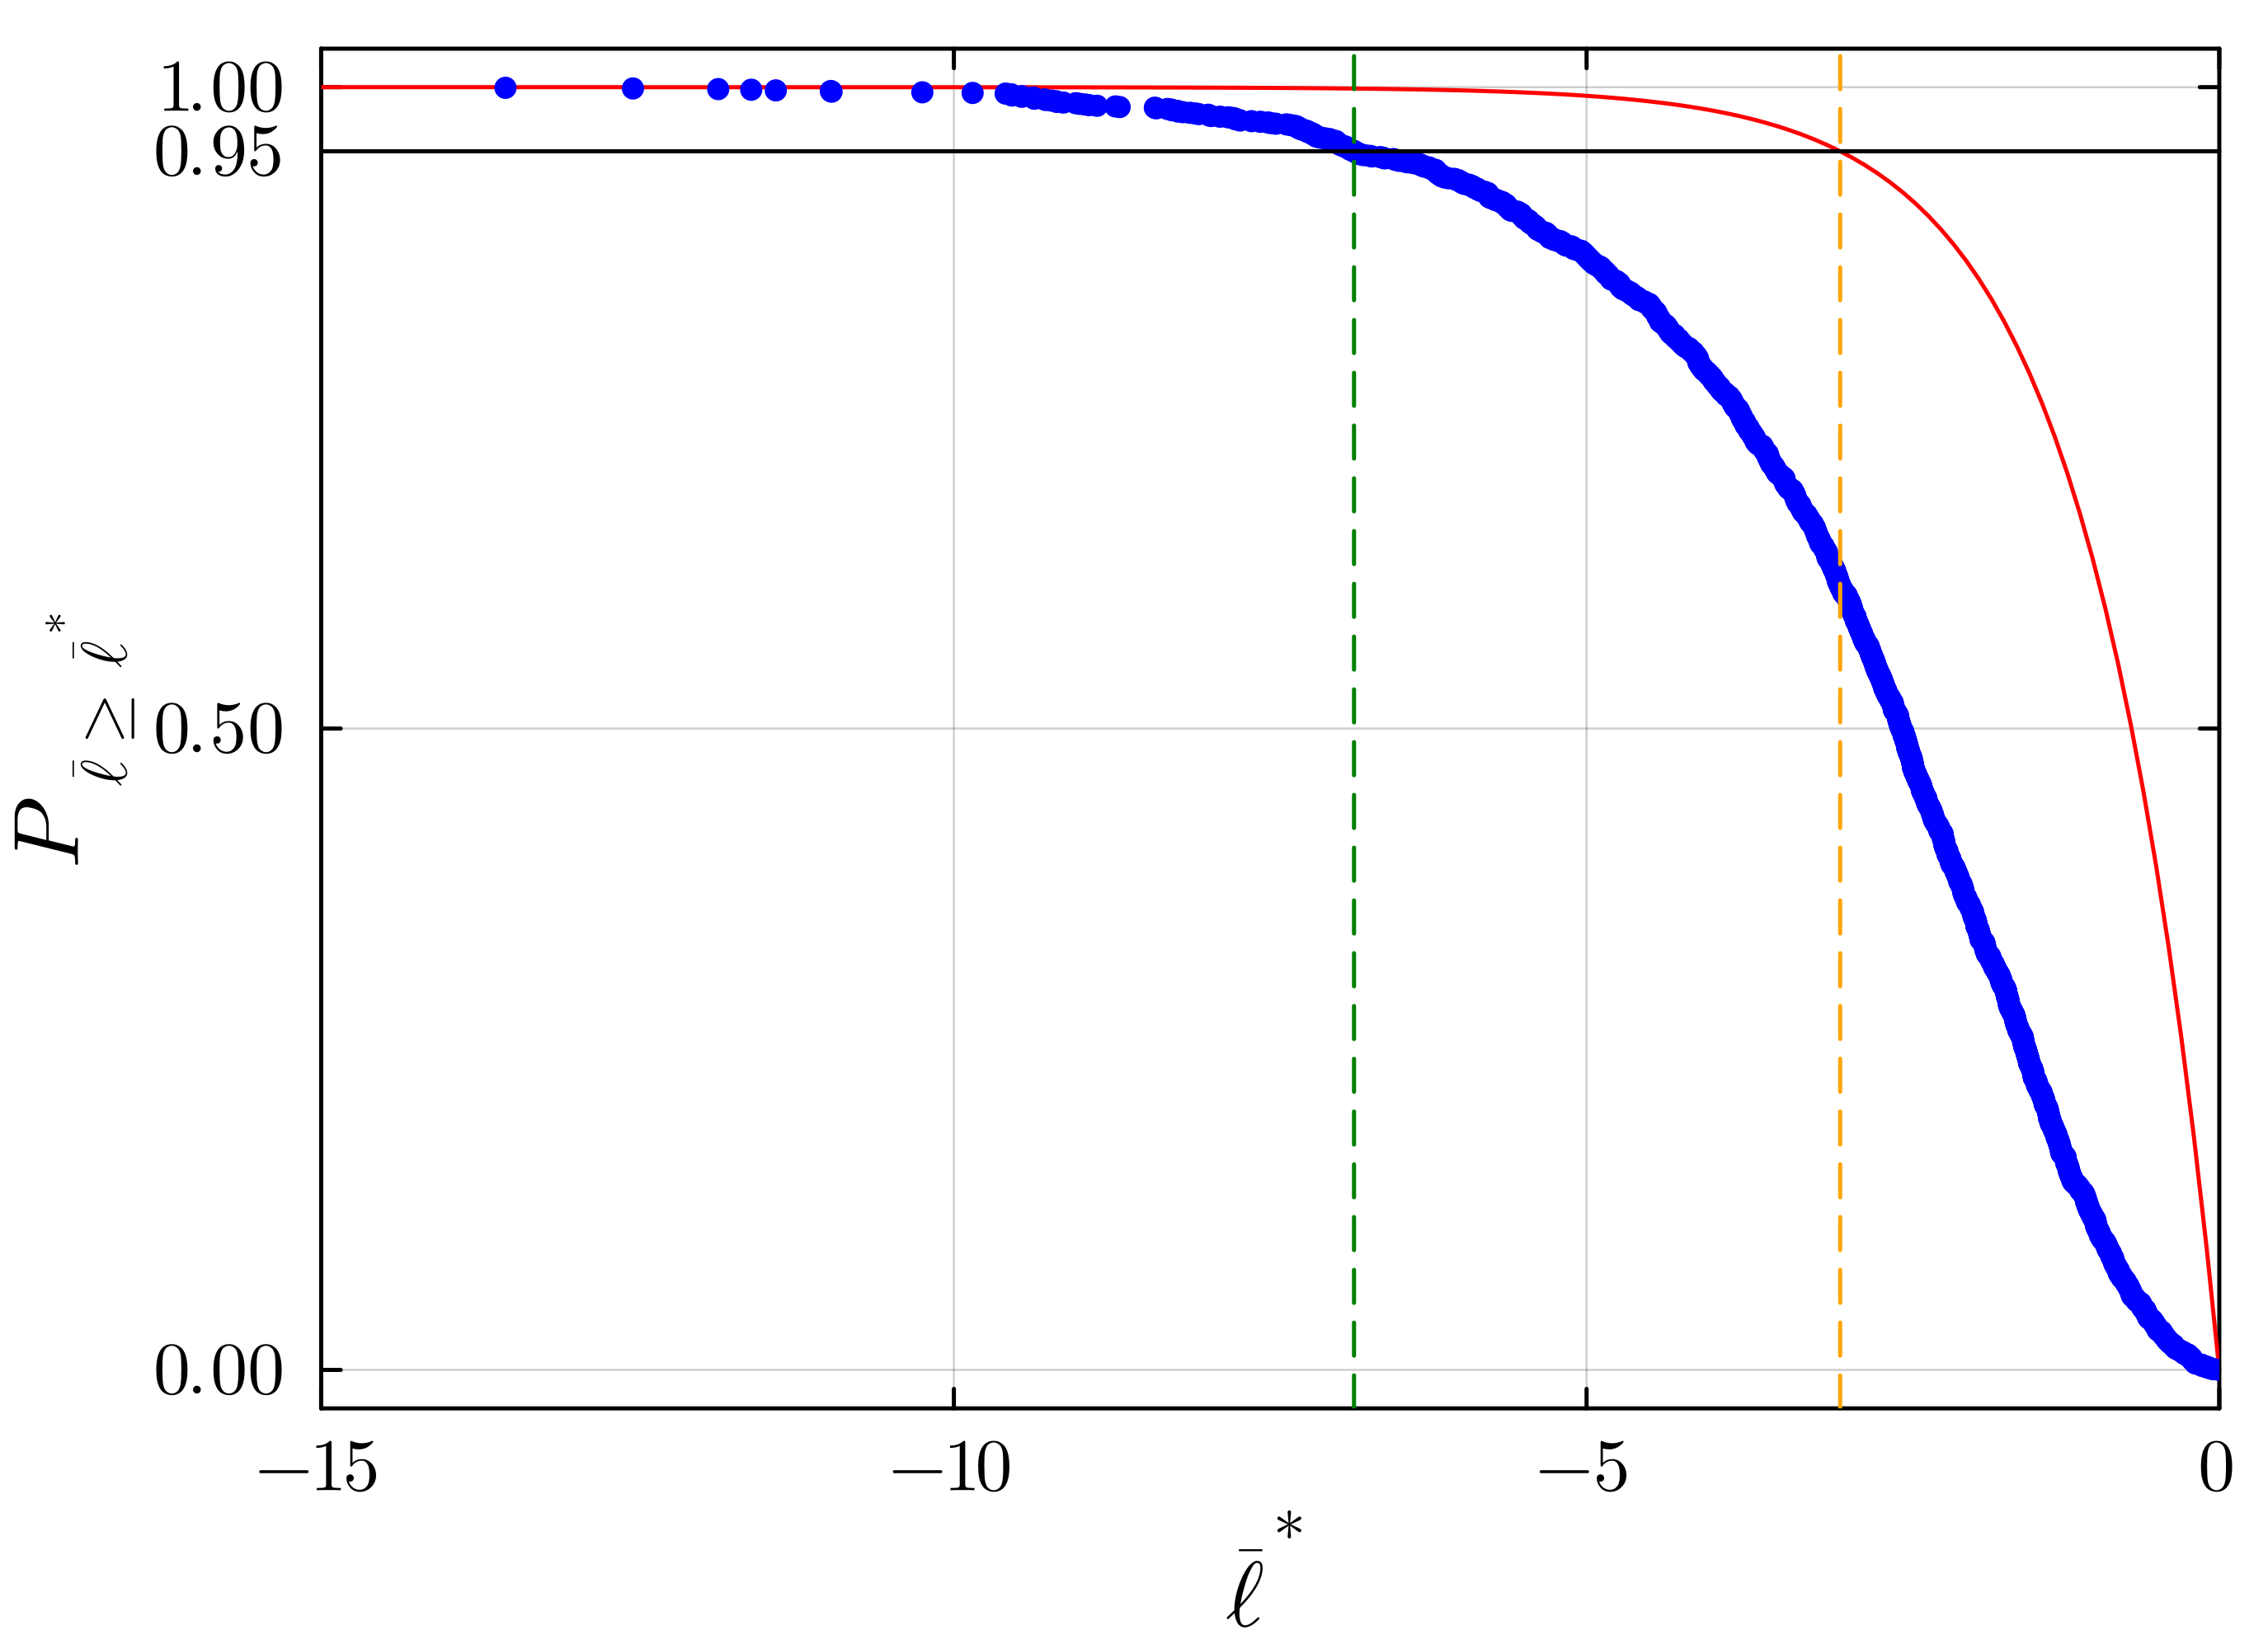

In [7]:
#Plotting the expected result for standard likelihood functions

# Define the x-range
x = -15:0.1:0

# Define the y-values using the CDF of a Chi-squared distribution
y = cdf.(Chisq(2), -2*x)

# Plot
p1 = plot(x, y, color = :red)
p1 = scatter!(l_bar_list_ranked_2000, 1 .-P_list_2000, dpi = 500, color = :blue, size = (550, 400), xticks=([-15, -10, -5, 0],[L"-15", L"-10", L"-5", L"0"]), yticks=([0, 0.5, 0.95, 1],[L"0.00", L"0.50", L"0.95", L"1.00"]), xlims = (-15, 0), markersize = 3, markerstrokewidth=0, xlabel = L"\bar{\ell}^{*}", ylabel = L"P_{\bar{\ell} \geq \bar{\ell}^{*}}", xguidefontsize=15, yguidefontsize=15,xtickfontsize=12, ytickfontsize=12)
p1 = hline!([0.95], color = :black)
p1 = vline!([l95], color = :green, linestyle = :dash)
p1 = vline!([-2.996], color = :orange, linestyle = :dash)

plot(p1)